### Import packages

In [760]:
import numpy as np
import pandas as pd

### Read the csv into our ipynb

In [761]:
data = pd.read_csv("Spam Email Detection - spam.csv")
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [762]:
data.shape

(5572, 5)

### Pipeline:

1) Data cleaning
2) EDA
3) Text Preprocessing
4) Model building
5) Evaluation
6) Improvement

In [763]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [764]:
#dropping the last 3 columns

data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [765]:
data.shape

(5572, 2)

In [766]:
data.head(2)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [767]:
data.rename(columns={
    'v1': 'Target',
    'v2': 'Mail-Text'
}, inplace = True)

In [768]:
data.head(2)

,Target,Mail-Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


### Encoding Data

In [769]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [770]:
# Not Spam = 0
# Spam = 1

data['Target'] = encoder.fit_transform(data['Target'])

In [771]:
data.sample(2)

,Target,Mail-Text
4159,0,i felt so...not any conveying reason.. Ese he....
226,1,Will u meet ur dream partner soon? Is ur caree...


### Check for missing values

In [772]:
data.isna().sum()

Target       0
Mail-Text    0
dtype: int64

### Check for duplicate values

In [773]:
data.duplicated().sum()

np.int64(409)

In [774]:
#drop duplicate values

data = data.drop_duplicates(keep = 'first')

In [775]:
data.shape

(5163, 2)

### 2) Data Viz

In [776]:
data['Target'].value_counts()

Target
0    4516
1     647
Name: count, dtype: int64

In [777]:
data.rename(columns={
    'Target':'Type'
}, inplace = True)

In [778]:
data.head(2)

,Type,Mail-Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...


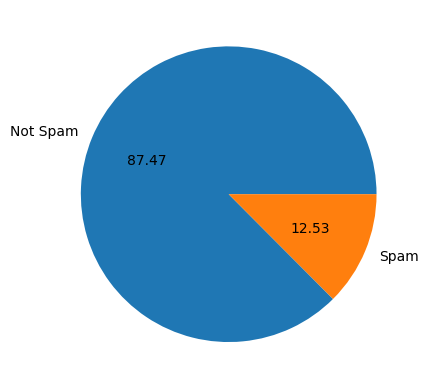

In [779]:
#pie chart


import matplotlib.pyplot as plt
plt.pie(data['Type'].value_counts(), labels=['Not Spam', 'Spam'], autopct="%0.2f")
plt.show()

### Turn data into a "balanced format"

In [780]:
import nltk

In [781]:
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/daiyabhavyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/daiyabhavyan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [782]:
#create a num_characters column which contains length of characters of each mail

data['Character Count'] = data['Mail-Text'].apply(len)

In [783]:
# data.drop(
#     columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
#     inplace=True
# )

In [784]:
data.head()

,Type,Mail-Text,Character Count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [785]:
#tokenize the sentence into number of words

data['Mail-Text'].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, �_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: Mail-Text, Length: 5163, dtype: object

In [786]:
#creating a Word count column

data['Word Count'] = data['Mail-Text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [787]:
data.head(2)

,Type,Mail-Text,Character Count,Word Count
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8


In [788]:
#create a Sentence count column by using "nltk.sent_tokenize"

data['Sentence Count'] = data['Mail-Text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [789]:
data.head(2)

,Type,Mail-Text,Character Count,Word Count,Sentence Count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2


In [790]:
data.describe()

,Type,Character Count,Word Count,Sentence Count
count,5163.000000,5163.000000,5163.000000,5163.000000
mean,0.125315,78.811156,18.444122,1.963974
std,0.331108,58.153491,13.327940,1.448008
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,116.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [791]:
#describe function for Not Spam:

data[data['Type'] == 0] [['Character Count', 'Word Count', 'Sentence Count']].describe()

,Character Count,Word Count,Sentence Count
count,4516.000000,4516.000000,4516.000000
mean,70.428919,17.123782,1.820195
std,56.356310,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [792]:
#describe function for  Spam:

data[data['Type'] == 1] [['Character Count', 'Word Count', 'Sentence Count']].describe()

,Character Count,Word Count,Sentence Count
count,647.000000,647.000000,647.000000
mean,137.318393,27.659969,2.967543
std,30.096861,7.038065,1.490069
min,13.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


In [793]:
import seaborn as sns

<Axes: xlabel='Character Count', ylabel='Count'>

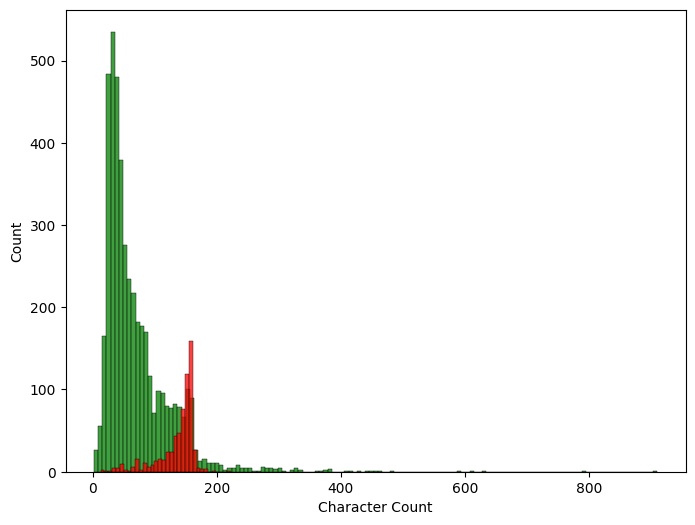

In [794]:
#histogram for Character Count

plt.figure(figsize=(8,6))
sns.histplot(data[data['Type']==0]['Character Count'], color = 'green')
sns.histplot(data[data['Type']==1]['Character Count'], color = 'red')

<Axes: xlabel='Word Count', ylabel='Count'>

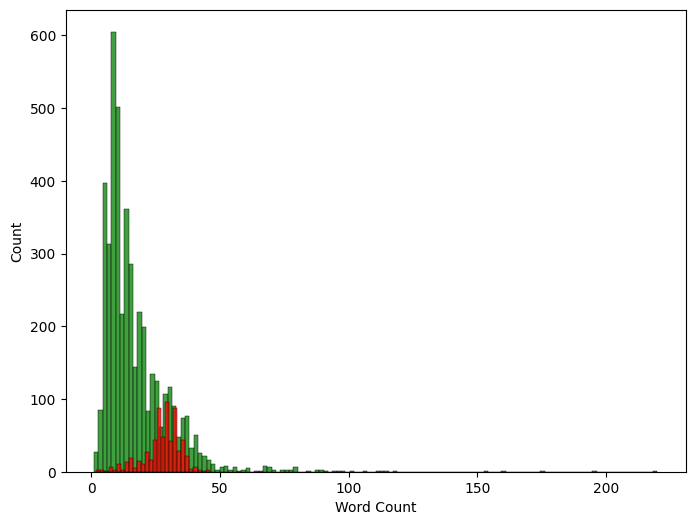

In [795]:
#histogram for Word Count

plt.figure(figsize=(8,6))
sns.histplot(data[data['Type']==0]['Word Count'], color = 'green')
sns.histplot(data[data['Type']==1]['Word Count'], color = 'red')

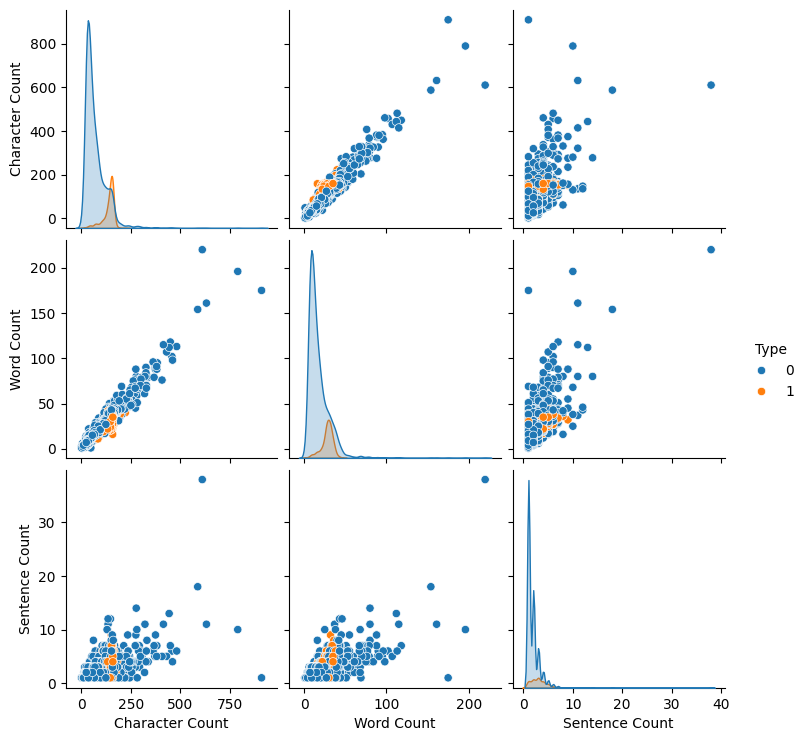

In [796]:
sns.pairplot(data, hue = "Type")

In [797]:
columns_to_select = ['Type', 'Character Count', 'Word Count', 'Sentence Count']
numeric_data = data[columns_to_select]

<Axes: >

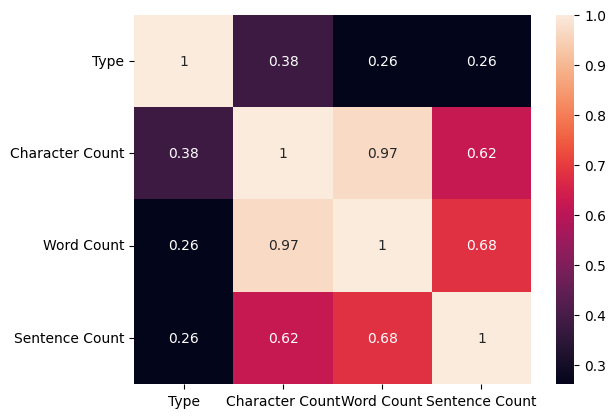

In [798]:
#heatmap

sns.heatmap(numeric_data.corr(), annot=True)

### 3) Text Preprocessing

1) lower case conversion
2) tokenization
3) removal of special characters
4) removal of stopwords & punctuations
5) stemming

In [799]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/daiyabhavyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [800]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [801]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [802]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Roaming')

'roam'

In [803]:
# function for 1-5

def transform_text(text):
    text = text.lower()     # 1) lower case conversion
    text = nltk.word_tokenize(text)     # 2) tokenization

    y = []      # 3) removal of special characters
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:      # 4) removal of stop words & punctuations
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:      # 5) stemming
        y.append(ps.stem(i))
    
    return " ".join(y)

In [804]:
transform_text('Okay name ur price as long as its legal! Wen can I pick them up? Y u ave x ams xx')

'okay name ur price long legal wen pick u ave x am xx'

In [805]:
data['Mail-Text'][100]

'Okay name ur price as long as its legal! Wen can I pick them up? Y u ave x ams xx'

In [806]:
data['Transformed-Text'] = data['Mail-Text'].apply(transform_text)

In [807]:
data.head(3)

,Type,Mail-Text,Character Count,Word Count,Sentence Count,Transformed-Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...


### Word cloud formation

In [808]:
from wordcloud import WordCloud

In [809]:
wc = WordCloud(width=1500, height=800, min_font_size=10, background_color='white')

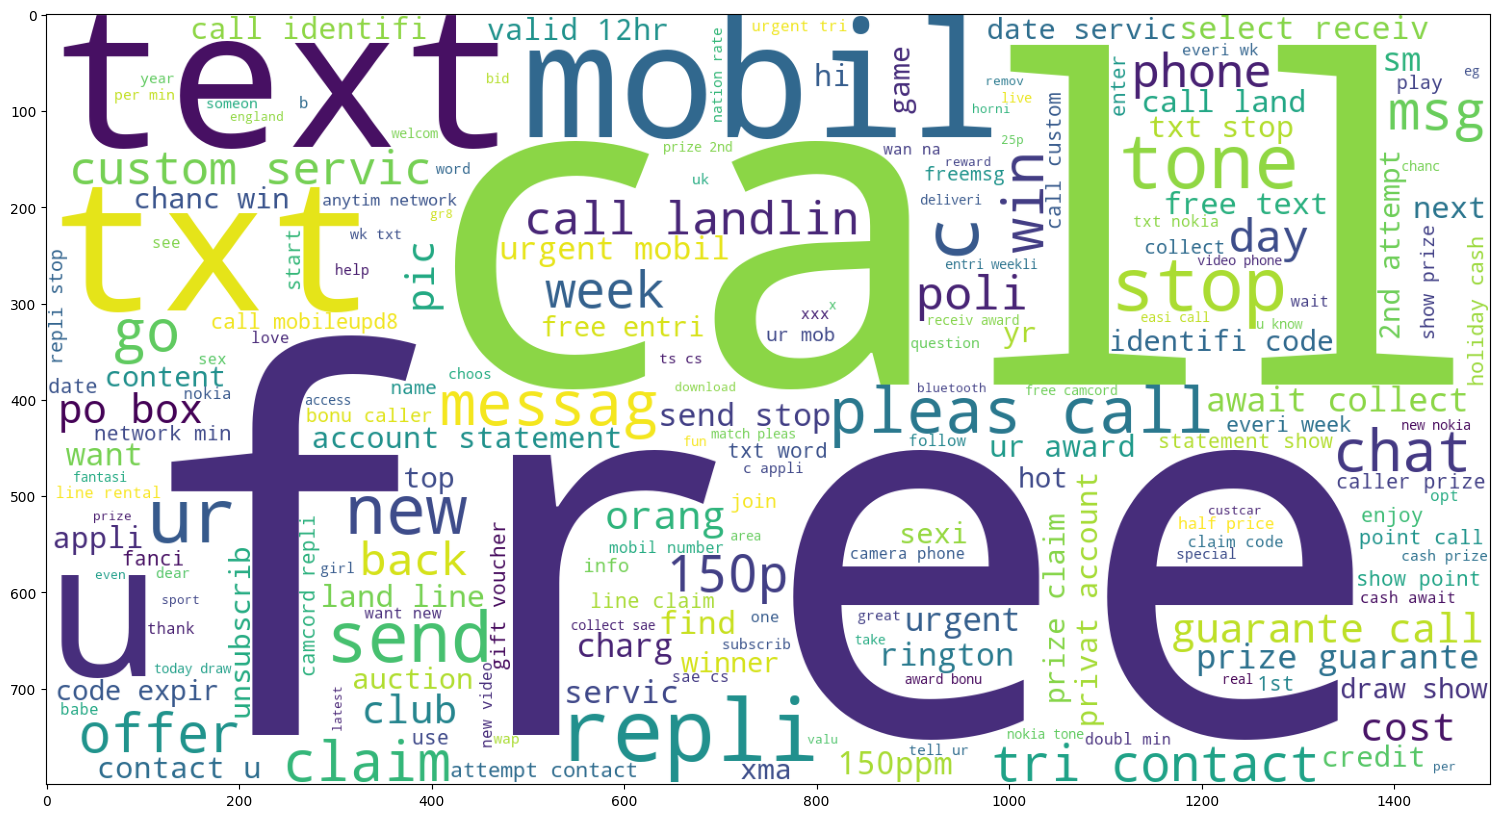

In [810]:
# Spam - wordcloud

spam_text = data.loc[data['Type'] == 1, 'Transformed-Text'].str.cat(sep=' ')
spam_wc = wc.generate(spam_text)

plt.figure(figsize=(20, 10))
plt.imshow(spam_wc)

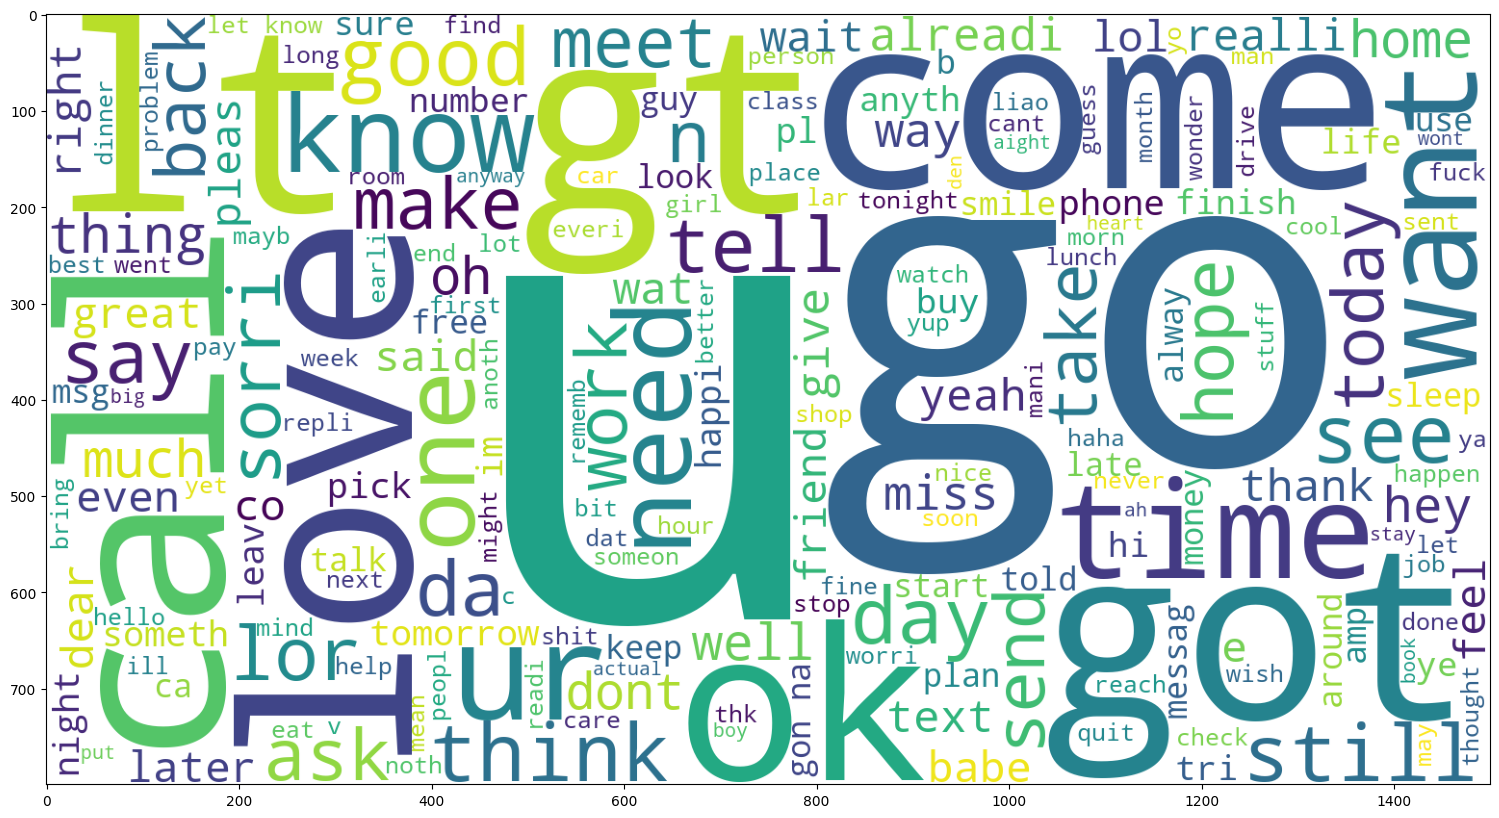

In [811]:
# Not Spam - wordcloud

not_spam_text = data.loc[data['Type'] == 0, 'Transformed-Text'].str.cat(sep=' ')
not_spam_wc = wc.generate(not_spam_text)

plt.figure(figsize=(20, 10))
plt.imshow(not_spam_wc)

In [812]:
spam_word = []
for msg in data[data['Type']==1]['Transformed-Text'].tolist():
    for word in msg.split():
        spam_word.append(word)

In [813]:
len(spam_word)

9861

In [814]:
from collections import Counter
Counter(spam_word)

Counter({'call': 316,
         'free': 188,
         '2': 155,
         'txt': 140,
         'text': 122,
         'ur': 119,
         'u': 117,
         'mobil': 110,
         'stop': 104,
         'repli': 103,
         'claim': 97,
         '4': 97,
         'prize': 80,
         'get': 73,
         'new': 64,
         'servic': 64,
         'tone': 63,
         'send': 59,
         'urgent': 57,
         'nokia': 55,
         'award': 55,
         'contact': 54,
         'phone': 52,
         'cash': 51,
         'pleas': 51,
         'week': 49,
         'win': 46,
         'c': 45,
         'min': 45,
         'collect': 44,
         'messag': 42,
         'guarante': 41,
         'per': 41,
         'custom': 40,
         'chat': 37,
         'tri': 36,
         'msg': 35,
         'number': 35,
         'cs': 35,
         'draw': 34,
         'today': 33,
         'offer': 33,
         'line': 33,
         'show': 32,
         'go': 32,
         'want': 31,
         'receiv': 3

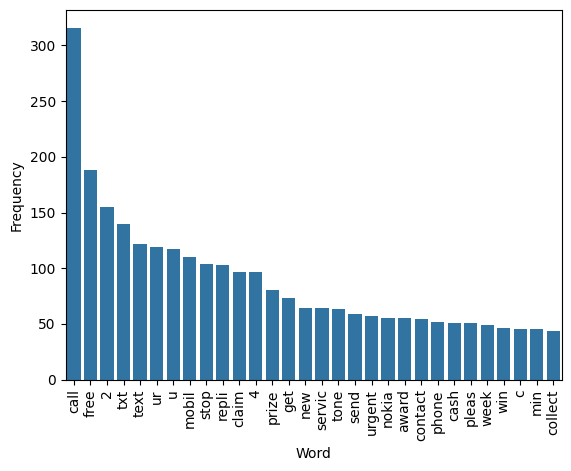

In [815]:
# plotting the most commonly used words in a spam email

data_frame = pd.DataFrame(Counter(spam_word).most_common(30), columns=['Word', 'Frequency'])
plt.figsize = (12, 5)
sns.barplot(x='Word', y="Frequency", data=data_frame)
plt.xticks(rotation='vertical')
plt.show()

In [816]:
not_spam_word = []
for msg in data[data['Type']==0]['Transformed-Text'].tolist():
    for word in msg.split():
        not_spam_word.append(word)

In [817]:
len(not_spam_word)

35306

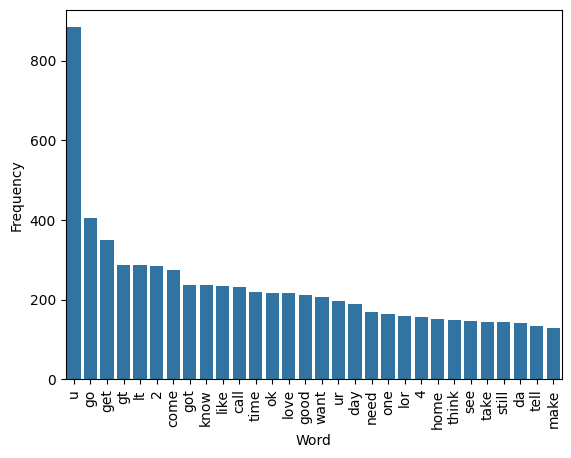

In [818]:
# plotting the most commonly used words in a Not Spam email

data_frame = pd.DataFrame(Counter(not_spam_word).most_common(30), columns=['Word', 'Frequency'])
plt.figsize = (12, 5)
sns.barplot(x='Word', y="Frequency", data=data_frame)
plt.xticks(rotation='vertical')
plt.show()

### 4) Model Building

In [819]:
data.head()

,Type,Mail-Text,Character Count,Word Count,Sentence Count,Transformed-Text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


### Using CountVectorizer

In [820]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [821]:
A = cv.fit_transform(data['Transformed-Text']).toarray()
A.shape

(5163, 6678)

In [822]:
b = data['Type'].values
print(b)

[0 0 1 ... 0 0 0]


In [823]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [824]:
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.2, random_state= 42)

In [825]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [826]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [827]:
#Gaussian Naive Bayes
print("Gaussian Naive Bayes: \n")
gnb.fit(A_train, b_train)
b_pred1 = gnb.predict(A_test)
print("Accuracy: ", accuracy_score(b_test, b_pred1)*100)
print("Confusion matrix: \n", confusion_matrix(b_test, b_pred1))
print("Precision score: ", precision_score(b_test, b_pred1))

Gaussian Naive Bayes: 

Accuracy:  86.83446272991287
Confusion matrix: 
 [[800 117]
 [ 19  97]]
Precision score:  0.4532710280373832


In [828]:
#Multinomial Naive Bayes
print("Multinomial Naive Bayes: \n")
mnb.fit(A_train, b_train)
b_pred2 = mnb.predict(A_test)
print("Accuracy: ", accuracy_score(b_test, b_pred2)*100)
print("Confusion matrix: \n", confusion_matrix(b_test, b_pred2))
print("Precision score: ", precision_score(b_test, b_pred2))

Multinomial Naive Bayes: 

Accuracy:  96.03097773475314
Confusion matrix: 
 [[892  25]
 [ 16 100]]
Precision score:  0.8


In [829]:
#Bernoulli Naive Bayes
print("Bernoulli Naive Bayes: \n")
bnb.fit(A_train, b_train)
b_pred3 = bnb.predict(A_test)
print("Accuracy: ", accuracy_score(b_test, b_pred3)*100)
print("Confusion matrix: \n", confusion_matrix(b_test, b_pred3))
print("Precision score: ", precision_score(b_test, b_pred3))

Bernoulli Naive Bayes: 

Accuracy:  96.32139399806388
Confusion matrix: 
 [[912   5]
 [ 33  83]]
Precision score:  0.9431818181818182


### Using TfidfVectorizer

In [830]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [831]:
X = tfidf.fit_transform(data['Transformed-Text']).toarray()

In [832]:
y = data['Type'].values
print(y)

[0 0 1 ... 0 0 0]


In [833]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 67)

In [834]:
#Gaussian Naive Bayes
print("Gaussian Naive Bayes: \n")

y_pred1 = gnb.predict(X_test)
print("Accuracy: \n", accuracy_score(y_test, y_pred1),)
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred1))
print("Precision Score: \n", precision_score(y_test, y_pred1))

Gaussian Naive Bayes: 

Accuracy: 
 0.9080348499515973
Confusion Matrix: 
 [[820  88]
 [  7 118]]
Precision Score: 
 0.5728155339805825


In [835]:
#Multinomial Naive Bayes
print("Multinomial Naive Bayes: \n")

y_pred2 = mnb.predict(X_test)
print("Accuracy: \n", accuracy_score(y_test, y_pred2),)
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred2))
print("Precision Score: \n", precision_score(y_test, y_pred2))

Multinomial Naive Bayes: 

Accuracy: 
 0.9874152952565344
Confusion Matrix: 
 [[907   1]
 [ 12 113]]
Precision Score: 
 0.9912280701754386


In [836]:
#Bernoulli Naive Bayes
print("Bernoulli Naive Bayes: \n")

y_pred3 = bnb.predict(X_test)
print("Accuracy: \n", accuracy_score(y_test, y_pred3),)
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred3))
print("Precision Score: \n", precision_score(y_test, y_pred3))

Bernoulli Naive Bayes: 

Accuracy: 
 0.9796708615682478
Confusion Matrix: 
 [[907   1]
 [ 20 105]]
Precision Score: 
 0.9905660377358491


### Model used: 
### Tfidf ------->> MultinomialNB (best results)

In [837]:
from sklearn.linear_model import LogisticRegression
from sklearn. svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [838]:
lr = LogisticRegression(solver = 'liblinear', penalty = 'l1')
sv = SVC(kernel = 'sigmoid', gamma=1.0)
mnb = MultinomialNB()
dct = DecisionTreeClassifier(max_depth=5)
knn = KNeighborsClassifier()
rf = RandomForestClassifier(n_estimators = 50, random_state = 42)
ab = AdaBoostClassifier(n_estimators = 50, random_state = 42)
bc = BaggingClassifier(n_estimators = 50, random_state = 42)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 42)
gb = GradientBoostingClassifier(n_estimators = 50, random_state = 42)
xgb = XGBClassifier(n_estimators = 50, random_state = 42)

In [839]:
# model training

models = {
    'Logistic Regression': lr,
    'SVC': sv,
    'MultinomialNB': mnb,
    'DecisionTreeClassifier': dct,
    'KNN': knn,
    'RF': rf,
    'AdaBoost': ab,
    'Bagging': bc,
    'Extra Tree': etc,
    'Gradient Boosting': gb,
    'XGBoost': xgb
}

In [840]:
#function to fit multiple models on X_train, X_test, y_train, y_test

def train_classifier(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision

In [841]:
# #testing for lr

# train_classifier(lr, X_train, X_test, y_train, y_test)

In [842]:
accuracy_scores = []
precision_scores = []

for name, model in models.items():
    c_accuracy, c_precision = train_classifier(model, X_train, X_test, y_train, y_test)
    print("For: ", name)
    print("Accuracy: ", c_accuracy)
    print("Precision: ", c_precision)

    accuracy_scores.append(c_accuracy)
    precision_scores.append(c_precision)

For:  Logistic Regression
Accuracy:  0.957405614714424
Precision:  0.9175257731958762


/Users/daiyabhavyan/Documents/Projects/Spam detection/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/daiyabhavyan/Documents/Projects/Spam detection/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For:  SVC
Accuracy:  0.9738625363020329
Precision:  0.9711538461538461
For:  MultinomialNB
Accuracy:  0.9641819941916747
Precision:  1.0
For:  DecisionTreeClassifier
Accuracy:  0.9409486931268151
Precision:  0.82
For:  KNN
Accuracy:  0.904162633107454
Precision:  1.0
For:  RF
Accuracy:  0.9748305905130688
Precision:  1.0
For:  AdaBoost
Accuracy:  0.9332042594385286
Precision:  0.8414634146341463
For:  Bagging
Accuracy:  0.9632139399806389
Precision:  0.859504132231405
For:  Extra Tree
Accuracy:  0.9709583736689255
Precision:  0.9797979797979798
For:  Gradient Boosting
Accuracy:  0.9593417231364957
Precision:  0.9770114942528736
For:  XGBoost
Accuracy:  0.9719264278799613
Precision:  0.9528301886792453


In [843]:
result_df = pd.DataFrame({'Algorithm': models.keys(), 'Accuracy': accuracy_scores, 'Precision': precision_scores}).sort_values('Precision', ascending = False)
result_df

,Algorithm,Accuracy,Precision
2,MultinomialNB,0.964182,1.000000
4,KNN,0.904163,1.000000
5,RF,0.974831,1.000000
8,Extra Tree,0.970958,0.979798
9,Gradient Boosting,0.959342,0.977011
1,SVC,0.973863,0.971154
10,XGBoost,0.971926,0.952830
0,Logistic Regression,0.957406,0.917526
7,Bagging,0.963214,0.859504
6,AdaBoost,0.933204,0.841463


In [844]:
result_df1 = pd.melt(result_df, id_vars = 'Algorithm')
result_df1

,Algorithm,variable,value
0,MultinomialNB,Accuracy,0.964182
1,KNN,Accuracy,0.904163
2,RF,Accuracy,0.974831
3,Extra Tree,Accuracy,0.970958
4,Gradient Boosting,Accuracy,0.959342
5,SVC,Accuracy,0.973863
6,XGBoost,Accuracy,0.971926
7,Logistic Regression,Accuracy,0.957406
8,Bagging,Accuracy,0.963214
9,AdaBoost,Accuracy,0.933204


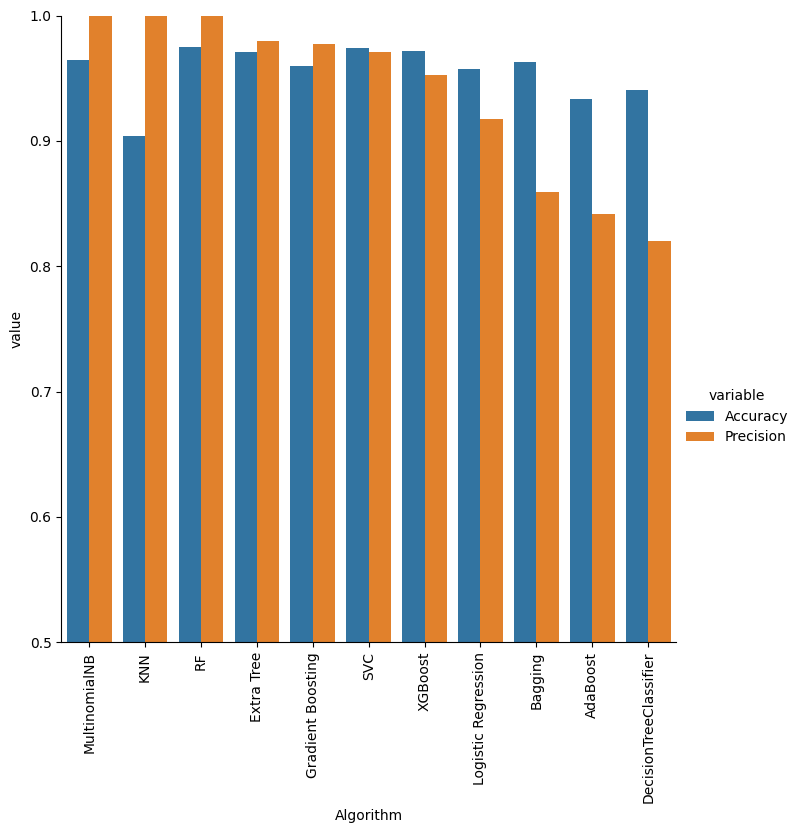

In [845]:
sns.catplot(x='Algorithm', y='value', hue='variable', data = result_df1, kind = 'bar', height = 7)
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()

In [846]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))